# Particle Swarm Optimizer

Particle Swarm Optimizer (PSO) is a type of bio-inspired optimization algorithm for finding the global minimum of a given problem. Modeled after animal swarms like flies, fish, and birds, PSO comprises several agents—points scattered throughout the solution space—which iteratively search for the global best solution. The agents explore the solution space while also moving towards the agent with the lowest cost such that all agents flock around the optimal solution at the end. Moreover, individual agents also have the memory of their personal best positions and only update their position when they find a better one. The velocity of the particles is governed by the inertia weight, which dictates how far the new position of the agent will be from its current position.

PSO is a metaheuristic optimization algorithm that does not need to make an assumption about the optimization problem. However, this also means that the algorithm may not always return accurate optimization results.

The PSO algorithm is as follows:

Initialize the agents of the swarm at random positions.
Evaluate the cost of each agent and find the global best agent, that is, the agent with the minimum cost.
Evaluate the velocities of the agents and update their positions.
If the cost of an agent’s current position is better than the cost of the personal best, update the personal best of the agent.
Repeat steps 2–4 until a criterion is met. This criterion can be a predetermined value of a global function or the number of iterations.

In [6]:
# Task 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [10]:
# Tasks 2-7: Implement the PSO algorithm
def particle_swarm_optimizer(n, cost, boundaries, N = 1000, W_lims = [0.9, 0.4], c1=2, c2 = 2):
    '''
    n: number of agents
    cost: The cost function
    boundaries: Bounds on solution space parameters
    N: Number of iterations, default set to 1000
    W_lims: The upper and lower limit of the acceleration weight
    c1, c2: Constants
    '''
    W = np.linspace(W_lims[0], W_lims[1], N)
    ### ENTER CODE HERE ###
    D = np.shape(boundaries)[0]
    # Data Arrays
    gb_arr = np.empty((N, D))
    cost_arr = []
    p_arr = np.empty((N, n, D))
    # Instantiate position of agents
    P = np.empty((n, D))
    # personal best
    Pb = np.empty((n, D))
    # instantiate velocities of agents
    v = np.empty((n, D))
    # Instantiating Pb and P
    for j in range(n):
        for k in range(D):
            delta = boundaries[k][1] - boundaries[k][0]
            P[j][k] = np.random.rand()*delta + boundaries[k][0]
            Pb[j][k] = P[j][k]
            # Instantiate v to random values
            v[j][k] = np.random.rand()*2*delta - delta

    for i in range(N):
        # update GBest
        costs = [cost(P[l]) for l in range(n)]
        ind_min = np.argmin(costs)
        Gb = P[ind_min]
        # Update velocities
        for j in range(n):
            v[j] = W[i]*v[j] + c1*np.random.rand()*(Pb[j] - P[j] + c2*np.random.rand()*((Gb - P[j])))
            P[j] = v[j] + P[j]
            for k in range(D):
                P[j][k] = np.clip(P[j][k], boundaries[k][0], boundaries[k][1])
            
            # Compare P[j] with Pb[j]
            if cost(P[j]) < cost(Pb[j]):
                Pb[j] = P[j]
        
        # Update the data arrays
        gb_arr[i] = Gb
        cost_arr.append(costs[ind_min])
        p_arr[i] = P
    ### ENTER CODE HERE ###
    return gb_arr, p_arr, cost_arr

In [11]:
# Task 8: Define the cost function
def cost(params):
    return (params[0] - 3.14)**2 + (params[1] - 2.72)**2 + np.sin(3*params[0] + .41) + np.sin(4*params[1] - 1.73)

In [12]:
# Task 9: Optimize the cost function
gb_arr, p_arr, cost_arr = particle_swarm_optimizer(10, cost, np.array([[0, 5], [0, 5]]), 250) 
print('The optimal solution: ', gb_arr[-1])
print('Cost of the optimal solution:', cost_arr[-1])

The optimal solution:  [3.4570778  3.13048007]
Cost of the optimal solution: -1.6874185847111463


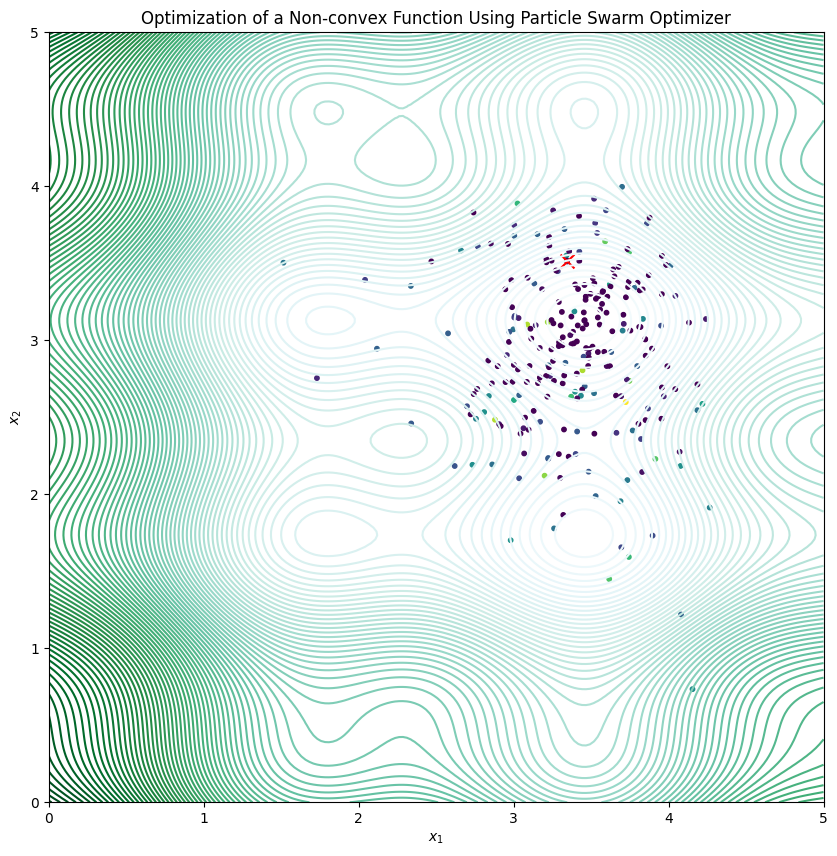

In [13]:
# Task 10: Visualize the results
# Data array
n = 200
x1 = np.linspace(0, 5, n)
x2 = np.linspace(0, 5, n)
# Grid of elements
X, Y = np.meshgrid(x1, x2)
# Cost function on grid
z = []
for y in Y:
    for x in X[0]:
        z.append(cost([x, y[0]]))
Z = np.reshape(z, (n, n))

# #Plotting the cost function of grid
fig = plt.figure(figsize = (10, 10))
plt.contour(X, Y, Z, cmap = 'BuGn', levels = 100)

# Plotting the optimization result
opt_arr = np.mean(p_arr, axis = 1)
param1, param2 = np.split(opt_arr, 2, axis = 1)
plt.scatter(param1, param2, c = cost_arr, s = 10, marker = 'o')

# Plotting the global minimum
plt.scatter(param1[-1], param2[-1], c = 'red', s = 100, marker = 'x')

# # Set labels
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title(r'Optimization of a Non-convex Function Using Particle Swarm Optimizer')  

plt.show()

In [14]:
# Task 11: Visualize the Swarm Motion
%matplotlib notebook

bounds = [[0, 5], [0, 5]]
levels = 100
[X, Y] = np.meshgrid(np.linspace(bounds[0][0], bounds[0][1], levels), np.linspace(bounds[1][0], bounds[1][1], levels))
Z = cost([X, Y])

fig = plt.figure(figsize = (7, 7))
plt.contour(X, Y, Z, levels)
gb, = plt.plot(gb_arr[0][0], gb_arr[0][0], 'ro', linestyle = '', markersize = 10)

p1, p2 = np.array_split(p_arr[0], 2, axis=1)
p,  = plt.plot(p1, p2, 'bx', linestyle = '', markersize = 5)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title(r'Motion of Agents in Particle Swarm Optimizer')  

def update(i, p, gb):
    gb.set_data(gb_arr[i][0], gb_arr[i][1])

    p1, p2 = np.array_split(p_arr[i], 2, axis=1)
    p.set_data(p1, p2)

    return p, gb,

anim = animation.FuncAnimation(fig, update, 2000, fargs = (p, gb), interval = 500,  blit=True, repeat=False)
plt.show()

<IPython.core.display.Javascript object>